In [34]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
import os

api_key = os.getenv("GOOGLE_API_KEY")

if os.environ['GOOGLE_API_KEY']:
    print("Google api key is set")
else:
    raise ValueError("Gemini API key is not set")


llm = ChatGoogleGenerativeAI(model="gemini-3.1-flash-lite", google_api_key=api_key, temperature=0.7)

Google api key is set


In [35]:
from langchain_core.tools import tool
from gmail_service import get_gmail_service
#get_email_thread(thread_id)
@tool
def get_new_emails(max_results = 10, search_query: str = ""):
    """
    Use this tool to access email and fetch new emails
    Args:
        search_query: the specific topic for which user wants to search email
    """
    service = get_gmail_service()

    results = service.users().messages().list(
        userId="me",
        maxResults=max_results,
        q = search_query
    ).execute()

    messages = results.get("messages", [])

    emails = []

    for message in messages:
        email = service.users().messages().get(
            userId="me",
            id=message["id"],
            format="full"
        ).execute()

        headers = email["payload"].get("headers", [])

        subject = ""
        sender = ""
        date = ""

        for header in headers:
            if header["name"] == "Subject":
                subject = header["value"]

            elif header["name"] == "From":
                sender = header["value"]

            elif header["name"] == "Date":
                date = header["value"]

        emails.append({
            "id": message["id"],
            "sender": sender,
            "subject": subject,
            "date": date
        })

    return emails

@tool
def search_internal_docs(query):
    """
    Use this tool to access internal documents required for email related issue or reply

    Args:
        query: To elaborate what type of document needed to be fetched
    """

@tool
def search_memory(query):
    """
    Use this tool to load previous conversation to handle to validate user requests

    Args:
        query: To elaborate what type of data to be loaded from memory for further process  
    """

@tool
def send_email(to, subject, body):
    """
    Use this tool to reply to customer or clients by generating a proper professional email

    Args:
        to: Holds email of user to whom email is to be send
        subject: Subject of the email
        body: content of the email
    """

In [36]:
tools = [get_new_emails, search_internal_docs, search_memory, send_email]

llm_with_tools = llm.bind_tools(tools)
result = llm_with_tools.invoke("Access my email to check latest unread mails")
result

AIMessage(content=[], additional_kwargs={'function_call': {'name': 'get_new_emails', 'arguments': '{"search_query": "is:unread"}'}, '__gemini_function_call_thought_signatures__': {'call_421582': 'EnEKbwERTTIPEGDl2l27OfdlcNFdgI7Ui6I2uLUT0RNzpAVGBfhs4yW3+JBMqflN+q8Iwe4jq/THJpXQHfJSUGzDkqm1PCpvQk35Xps1a5VwvZBUOuKYZ3+uKY9+AiHxq+QkdTwbbPv4tcMI3HphaY/eVA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a07029-5567-75d0-8016-e01bbad865ee-0', tool_calls=[{'name': 'get_new_emails', 'args': {'search_query': 'is:unread'}, 'id': 'call_421582', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 335, 'output_tokens': 22, 'total_tokens': 357, 'input_token_details': {'cache_read': 0}})

In [37]:
from typing import TypedDict, Annotated, List, Optional
from langgraph.graph.message import BaseMessage, add_messages
from pydantic import BaseModel, Field

class email_automation_schema(BaseModel):
    filtered_result: Optional[list] = Field(description="stores only those mails that needs to be observed or require response/reply")
    answer: str

class graph_schema(TypedDict):
    query: Annotated[List[BaseMessage], add_messages]
    tool_response: list
    filtered_result: list = Field(description="stores only those mails that needs to be observed or require response/reply")
    answer: str

In [38]:
llm_with_schema = llm.with_structured_output(email_automation_schema)

In [39]:
from langchain_core.messages import ToolMessage, AIMessage, HumanMessage
from langchain_core.prompts import ChatPromptTemplate
def llm_node(state: graph_schema) -> graph_schema:
    query = state['query']
    print(f"Your query{query}")
    response = llm_with_tools.invoke(query)

    print(response)
    return {
        "query": [response]
    }

def tool_node(state: graph_schema) -> graph_schema:

    query = state['query'][-1]
    print(f"Tool node:{query}")
    tool_name = {tool.name: tool for tool in tools}

    tool_result = []

    for tool_call in query.tool_calls:
        tool = tool_name[tool_call["name"]]

        observation = tool.invoke(tool_call['args'])

        tool_result.append(ToolMessage(content=str(observation), tool_call_id=tool_call['id']))

    return {
        'query': tool_result
    }

def tool_decision(state: graph_schema) -> str:
    if state['query'][-1].tool_calls:
        return "tool_node"
    else:
        return "end"

def evaluator_node(state: graph_schema) -> graph_schema:
    tool_response = state['tool_response']

    prompt = ChatPromptTemplate.from_messages([
        ('system', """You are professional mail generator that help user draft a mail if they ask you to
        
        - Check for only those mails that is required to be observed needs a reply
        - If email needs reply tell how many mails require reply
        - else just summarize the mails as it is.
        """),
        ('user', """
            raw_result: {tool_response}
""")
    ])

    chain = prompt | llm_with_schema
    response = chain.invoke({"tool_response": tool_response})

    print(f"Response after evaluator funtion: {response}")
    return {
        "answer": response.answer,
        "filtered_result": response.filtered_result
    }

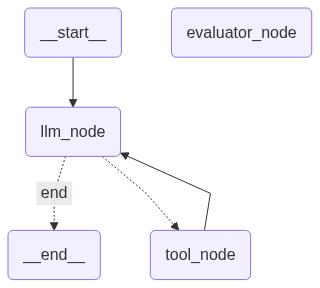

In [40]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node", llm_node)
graph.add_node("tool_node", tool_node)
graph.add_node("evaluator_node", evaluator_node)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node", tool_decision, {"tool_node": "tool_node", "end": END})
graph.add_edge("tool_node", "llm_node")
graph.add_edge("llm_node", END)

email_agent = graph.compile()
email_agent

In [ ]:
conversation = []

while True:
    query = input("Enter a query to proceed (stop to end task...)")

    if query == "stop":
        break

    conversation.append(HumanMessage(content=query))

    response = email_agent.invoke({
        "query": conversation,
        "answer": "",
        "filtered_result": []
    })

    print(response['query'])
    if response['filtered_result']:
        conversation.append(
            AIMessage(
                content=f"Emails requiring reply: {response['filtered_result']}"
            )
        )
        
    conversation.append(AIMessage(content=response['answer']))

Your query[HumanMessage(content='access my emails and check for unread mails that require reply', additional_kwargs={}, response_metadata={}, id='9755670d-6966-4162-89aa-15ec62b10e7f')]
content=[] additional_kwargs={'function_call': {'name': 'get_new_emails', 'arguments': '{"search_query": "is:unread"}'}, '__gemini_function_call_thought_signatures__': {'call_421991': 'EnEKbwERTTIP1nZIp4kWH6idux6sQVU9E5qCQhkDkNIMtSTA9t7MkNbasrCJCSbXN61ki2fbS8KL66ND4yl4QcDXAu4jDpJm8cpSSxFQcNjq3cfHrMIENpqL2OWCGTNMQ/ZxSGSiuBHLbJC8s9gBM/8PsQ=='}} response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'} id='lc_run--01a07029-77ec-73b1-8974-c823694f506c-0' tool_calls=[{'name': 'get_new_emails', 'args': {'search_query': 'is:unread'}, 'id': 'call_421991', 'type': 'tool_call'}] invalid_tool_calls=[] usage_metadata={'input_tokens': 338, 'output_tokens': 22, 'total_tokens': 360, 'input_token_details': {'cache_read': 0}}
Tool node:cont